# 01 — Exploratory Data Analysis

Inspects raw inputs, plots spatially-averaged time series and missing-value heatmaps, and runs the two stationarity diagnostics for SPEI3 (Mann-Kendall trend, KS pre/post-1990).

Run *after* `inputs/era5-inputs.nc` has been updated to include RZSM (Rootzone Soil Moisture, 0–100 cm) in place of SSMI.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the package importable when run from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import data as ddata

config = ddata.load_config(ROOT / 'configs' / 'data.yaml')
config

{'paths': {'cru': '/Users/workad/Workspace/A4-DroughtForecasting-Modeling/inputs/cru-inputs.nc',
  'era5': '/Users/workad/Workspace/A4-DroughtForecasting-Modeling/inputs/era5-inputs.nc',
  'climate_indices': '/Users/workad/Workspace/A4-DroughtForecasting-Modeling/inputs/climate_indices.nc',
  'spei3': '/Users/workad/Workspace/A4-DroughtForecasting-Modeling/inputs/SPEI3.nc'},
 'time_period': {'start': '1950-01', 'end': '2024-12'},
 'variable_renames': {'cru': {'pre': 'precip',
   'tmn': 'tmin',
   'tmx': 'tmax',
   'pet': 'pet'},
  'era5': {'ssrd': 'solar',
   'si2': 'wind',
   'vpd': 'vpd',
   'tcwv': 'tcwv',
   'rzsm': 'rzsm'},
  'climate_indices': {'Nino34': 'enso', 'NAO': 'nao', 'MO_std': 'mo'},
  'spei3': {'spei3': 'spei3'}},
 'sort_lat_ascending': True,
 'missing_values': {'strategy': 'interpolate',
  'max_gap_months': 2,
  'cell_missing_frac_threshold': 0.05},
 'stationarity': {'mann_kendall_alpha': 0.05, 'ks_test_split_year': 1990}}

## Load all inputs

In [2]:
datasets = ddata.load_all(config)
for name, ds in datasets.items():
    print(f"{name}: dims={dict(ds.sizes) if hasattr(ds, 'sizes') else ds.shape}")
    print(f"  vars: {list(ds.data_vars) if isinstance(ds, xr.Dataset) else ds.name}")
    print()

cru: dims={'lon': 64, 'lat': 64, 'time': 900}
  vars: ['precip', 'tmin', 'tmax', 'pet']

era5: dims={'time': 900, 'lat': 64, 'lon': 64}
  vars: ['solar', 'wind', 'vpd', 'tcwv', 'rzsm']

indices: dims={'time': 900}
  vars: ['enso', 'nao', 'mo']

spei3: dims={'time': 900, 'lat': 64, 'lon': 64}
  vars: ['spei3']



## Spatially-averaged time series

Quick sanity check that the data spans 1950–2024 and shows expected seasonality.

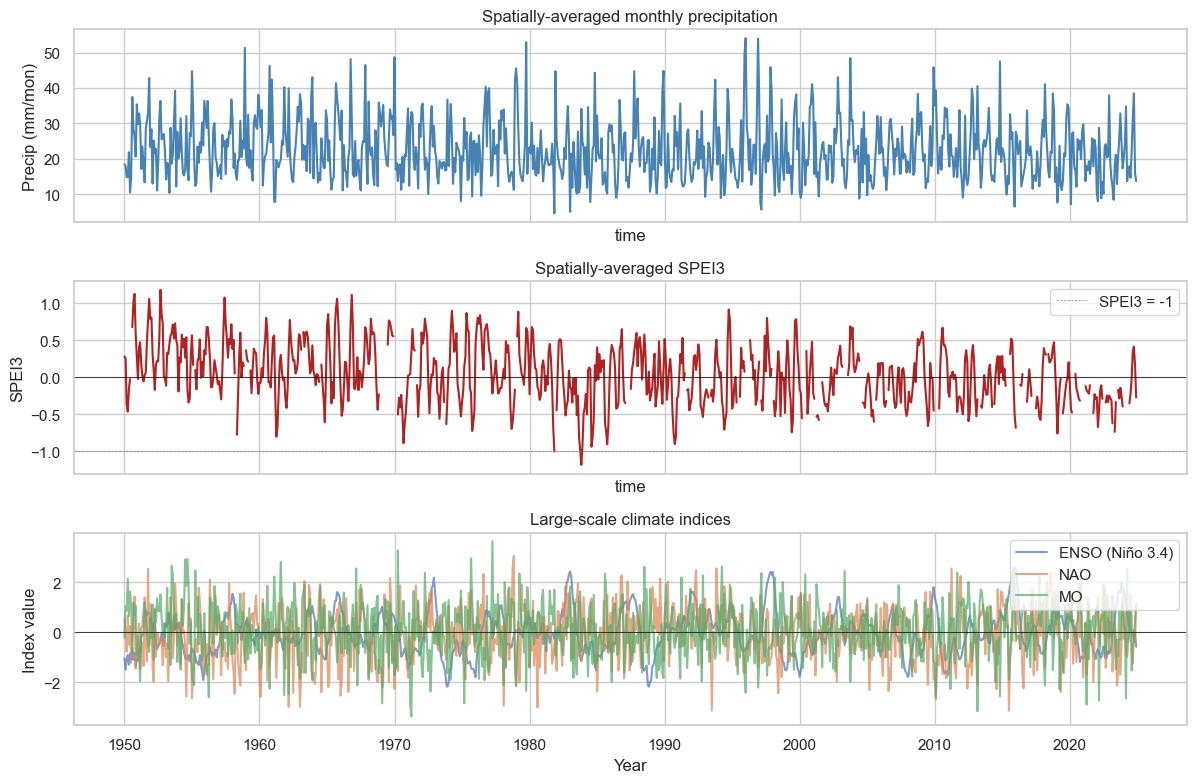

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

precip = datasets['cru']['precip'].mean(dim=['lat', 'lon'])
precip.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Precip (mm/mon)')
axes[0].set_title('Spatially-averaged monthly precipitation')

spei3 = datasets['spei3']['spei3'].mean(dim=['lat', 'lon'])
spei3.plot(ax=axes[1], color='firebrick')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhline(-1, color='gray', linestyle='--', linewidth=0.5, label='SPEI3 = -1')
axes[1].set_ylabel('SPEI3')
axes[1].set_title('Spatially-averaged SPEI3')
axes[1].legend(loc='upper right')

axes[2].plot(datasets['indices']['time'], datasets['indices']['enso'], label='ENSO (Niño 3.4)', alpha=0.7)
axes[2].plot(datasets['indices']['time'], datasets['indices']['nao'], label='NAO', alpha=0.7)
axes[2].plot(datasets['indices']['time'], datasets['indices']['mo'], label='MO', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Index value')
axes[2].set_title('Large-scale climate indices')
axes[2].legend(loc='upper right')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

## Missing-value heatmaps

Per-cell fraction of NaNs across the time dimension, for each gridded variable.

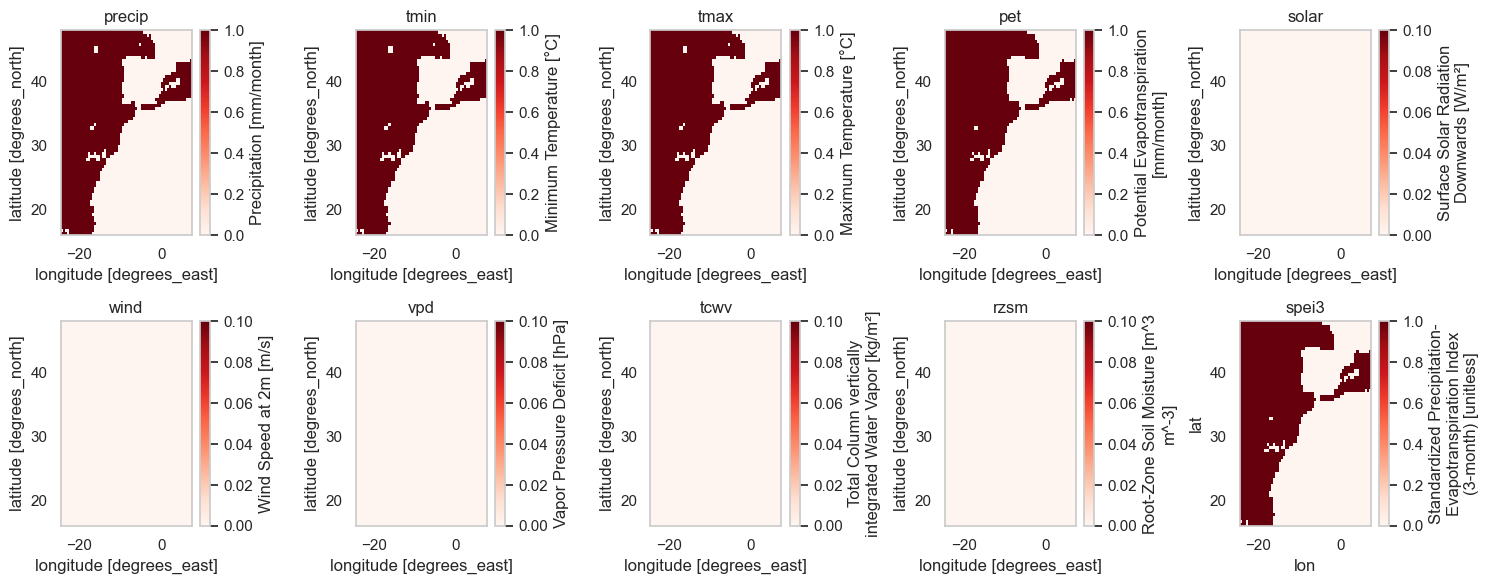

In [4]:
gridded_vars = {
    'precip': datasets['cru']['precip'],
    'tmin': datasets['cru']['tmin'],
    'tmax': datasets['cru']['tmax'],
    'pet': datasets['cru']['pet'],
    'solar': datasets['era5']['solar'],
    'wind': datasets['era5']['wind'],
    'vpd': datasets['era5']['vpd'],
    'tcwv': datasets['era5']['tcwv'],
    'rzsm': datasets['era5']['rzsm'],
    'spei3': datasets['spei3']['spei3'],
}

n = len(gridded_vars)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten()
for i, (name, da) in enumerate(gridded_vars.items()):
    frac = ddata.cell_missing_fraction(da)
    frac.plot(ax=axes[i], cmap='Reds', vmin=0, vmax=max(0.1, float(frac.max())))
    axes[i].set_title(name)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## SPEI3 distribution

ValueError: supplied range of [-inf, 3.78949937208763] is not finite

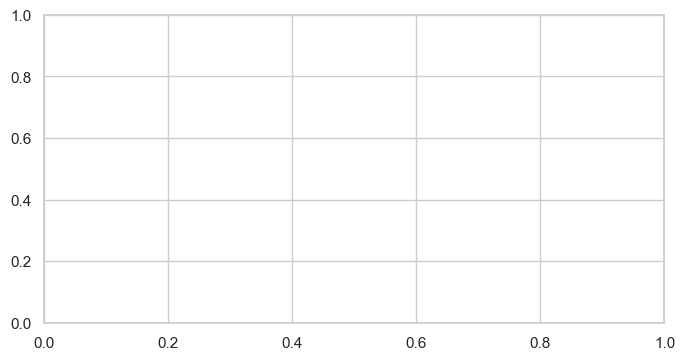

In [5]:
spei3_flat = datasets['spei3']['spei3'].values.flatten()
spei3_flat = spei3_flat[~np.isnan(spei3_flat)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(spei3_flat, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
for thresh, label, color in [(-2.0, 'Extreme', 'darkred'), (-1.5, 'Severe', 'red'),
                              (-1.0, 'Moderate', 'orange'), (1.0, 'Wet', 'green')]:
    ax.axvline(thresh, color=color, linestyle='--', alpha=0.7, label=f'{label} ({thresh})')
ax.set_xlabel('SPEI3')
ax.set_ylabel('Count')
ax.set_title(f'SPEI3 distribution over 1950–2024 (N = {len(spei3_flat):,})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"mean = {spei3_flat.mean():.3f}, std = {spei3_flat.std():.3f}, skew = {pd.Series(spei3_flat).skew():.3f}")

## Stationarity diagnostic 1 — Mann-Kendall trend test (annual SPEI3)

In [ ]:
mk_pmap = ddata.mann_kendall_pvalue_map(datasets['spei3']['spei3'])

fig, ax = plt.subplots(figsize=(9, 6))
alpha = config['stationarity']['mann_kendall_alpha']
mk_pmap.plot(ax=ax, cmap='RdYlBu', vmin=0, vmax=1, cbar_kwargs={'label': 'p-value'})
ax.set_title(f'Mann-Kendall trend test (annual SPEI3, 1950–2024); cells with p < {alpha} have significant trend')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

frac_sig = float((mk_pmap < alpha).mean())
print(f"Fraction of cells with significant trend (p < {alpha}): {frac_sig:.1%}")

## Stationarity diagnostic 2 — KS test (pre/post-1990 SPEI3 distributions)

In [ ]:
split_year = config['stationarity']['ks_test_split_year']
ks_pmap = ddata.ks_pvalue_map(datasets['spei3']['spei3'], split_year=split_year)

fig, ax = plt.subplots(figsize=(9, 6))
ks_pmap.plot(ax=ax, cmap='RdYlBu', vmin=0, vmax=1, cbar_kwargs={'label': 'p-value'})
ax.set_title(f'KS test: SPEI3 pre-{split_year} vs post-{split_year} (small p = distributions differ)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

frac_diff = float((ks_pmap < 0.05).mean())
print(f"Fraction of cells where distributions differ (p < 0.05): {frac_diff:.1%}")

## Notes

- A high fraction of significant Mann-Kendall trends would indicate non-stationarity in SPEI3 over the study period — this is *diagnostic*, not a gating criterion.
- A high fraction of cells failing the KS test indicates a structural shift in the SPEI3 distribution around 1990. The full-record SPEI3 fitting compromise (v2 scheme §2.e) should be revisited if this is widespread.
- These results should be summarized in the supplementary material of the paper.